## The script is used for the unsupervised analysis which calculates the Kurskal Wallis effect size

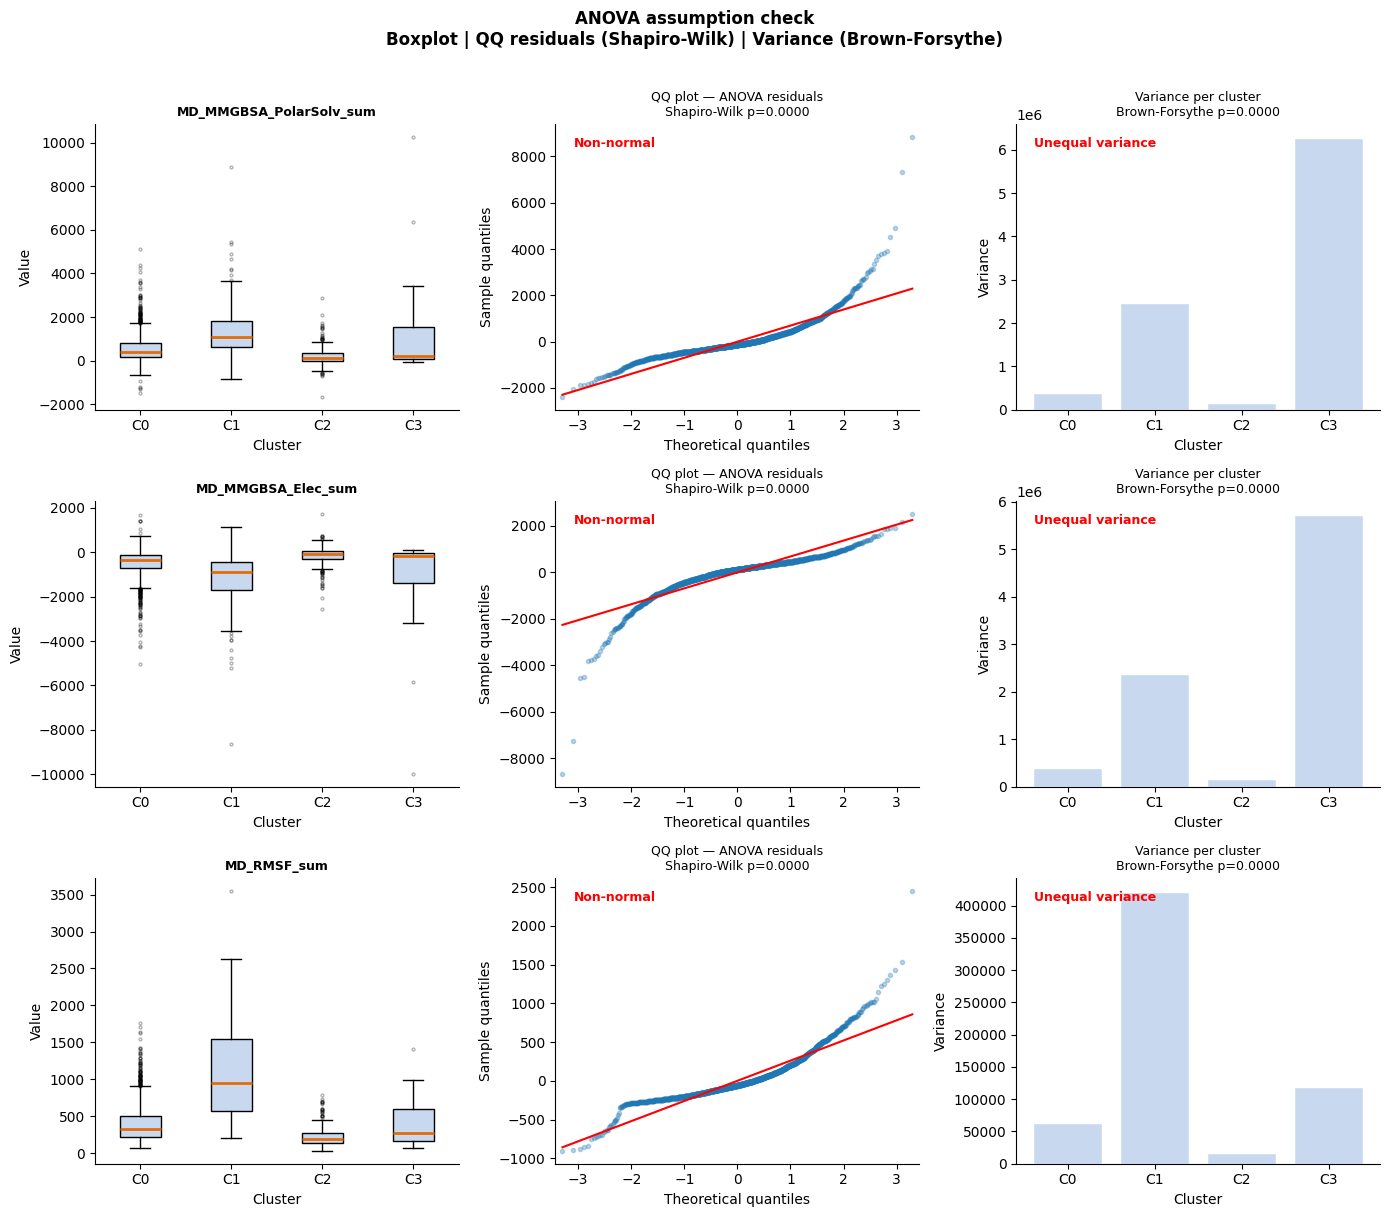

,feature,p_shapiro,p_levene,normal,equal_var
0,MD_MMGBSA_VdW_mean,1.326523e-04,1.204214e-09,False,False
1,MD_MMGBSA_Elec_mean,2.424079e-40,5.720159e-01,False,True
2,MD_MMGBSA_PolarSolv_mean,2.752062e-40,5.214431e-01,False,True
3,MD_MMGBSA_NonPolarSolv_mean,1.908719e-08,1.719331e-08,False,False
4,MD_RMSF_mean,3.640957e-29,4.577925e-06,False,False
...,...,...,...,...,...
60,Contact_per_Interface,2.697078e-18,1.214839e-10,False,False
61,AF_Fraction_Disordered,4.947421e-71,2.586613e-25,False,False
62,MD_MMGBSA_total,1.429638e-36,5.508349e-54,False,False
63,MD_MMGBSA_Std_Dev,5.329191e-06,1.089031e-02,False,False


In [1]:
# ══════════════════════════════════════════════════════════════
# ANOVA ASSUMPTION CHECK 
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, levene, bartlett
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from scipy.stats import chi2_contingency, kruskal, f_oneway

# ── config ────────────────────────────────────────────────────
QIN_PATH    = '../results/classical_agg_10_vbgmm_QIn.npy'
EXPIDS_PATH = '../source/agg_trans.csv'
N_FEATURES  = 3   # features to plot in detail

# ── load ──────────────────────────────────────────────────────
QIn    = np.load(QIN_PATH)
exp_df = pd.read_csv(EXPIDS_PATH)
df     = pd.DataFrame({'cluster_assignment': QIn.argmax(axis=1),
                       'ExpID': exp_df['ExpID'].values})
df = df.merge(exp_df, on='ExpID', how='left')

skip = {'cluster_assignment', 'ExpID', 'Transmembrane', 'label'}
feat_cols = [c for c in df.columns if c not in skip
             and pd.api.types.is_numeric_dtype(df[c])]
cluster_order = sorted(df['cluster_assignment'].unique())

# pick N features with most variance across clusters for visual check
top_feats = (df.groupby('cluster_assignment')[feat_cols]
               .mean().std().nlargest(N_FEATURES).index.tolist())


# ── FIGURE 1: per-feature diagnostic ─────────────────────────
fig, axes = plt.subplots(N_FEATURES, 3, figsize=(14, 4*N_FEATURES))

for row, feat in enumerate(top_feats):
    clean = df[['cluster_assignment', feat]].dropna()

    # ── fit proper ANOVA model via statsmodels ────────────────
    model = ols(f'{feat} ~ C(cluster_assignment)', data=clean).fit()
    residuals = model.resid  # ANOVA residuals

    # ── Shapiro-Wilk on ANOVA residuals ──────────────────────
    _, p_sw = shapiro(residuals)

    # ── Levene's test (robust, doesn't assume normality) ──────
    groups = [clean.loc[clean['cluster_assignment']==c, feat].values
              for c in cluster_order]
    _, p_lev = levene(*groups, center='median')  # median = Brown-Forsythe variant, mean is Levene

    # col 0: boxplot
    ax = axes[row, 0]
    ax.boxplot(groups, tick_labels=[f"C{c}" for c in cluster_order],
               patch_artist=True,
               boxprops=dict(facecolor='#C8D9EF'),
               medianprops=dict(color='#E36C09', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Cluster'); ax.set_ylabel('Value')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # col 1: QQ plot of proper ANOVA residuals
    ax = axes[row, 1]
    sm.qqplot(residuals, line='s', ax=ax, alpha=0.3, markersize=3)  # statsmodels QQ
    ax.set_title(f'QQ plot — ANOVA residuals\nShapiro-Wilk p={p_sw:.4f}', fontsize=9)
    ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Sample quantiles')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    c = 'green' if p_sw > 0.05 else 'red'
    ax.text(0.05, 0.92, 'Normal' if p_sw > 0.05 else 'Non-normal',
            transform=ax.transAxes, color=c, fontweight='bold', fontsize=9)

    # col 2: variance bar + Levene (Brown-Forsythe)
    ax = axes[row, 2]
    ax.bar([f"C{c}" for c in cluster_order],
           [np.var(g, ddof=1) for g in groups],
           color='#C8D9EF', edgecolor='white')
    ax.set_title(f'Variance per cluster\nBrown-Forsythe p={p_lev:.4f}', fontsize=9)
    ax.set_xlabel('Cluster'); ax.set_ylabel('Variance')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    c = 'green' if p_lev > 0.05 else 'red'
    ax.text(0.05, 0.92, 'Equal variance' if p_lev > 0.05 else 'Unequal variance',
            transform=ax.transAxes, color=c, fontweight='bold', fontsize=9)

plt.suptitle('ANOVA assumption check\nBoxplot | QQ residuals (Shapiro-Wilk) | Variance (Brown-Forsythe)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


# ── FIGURE 2: summary across ALL features ────────────────────
norm_fail, lev_fail, total = 0, 0, 0
results = []

for feat in feat_cols:
    clean = df[['cluster_assignment', feat]].dropna()
    groups = [clean.loc[clean['cluster_assignment']==c, feat].values
              for c in cluster_order]
    groups = [g for g in groups if len(g) > 2]
    if len(groups) < 2: continue
    total += 1

    # proper ANOVA residuals via statsmodels
    model = ols(f'{feat} ~ C(cluster_assignment)', data=clean).fit()
    _, p_sw  = shapiro(model.resid)
    _, p_lev = levene(*groups, center='median')

    norm_fail += p_sw  < 0.05
    lev_fail  += p_lev < 0.05
    results.append({'feature': feat, 'p_shapiro': p_sw, 'p_levene': p_lev,
                    'normal': p_sw >= 0.05, 'equal_var': p_lev >= 0.05})

res_df = pd.DataFrame(results)
res_df

In [2]:
basepath="../"
## set the path
import sys
sys.path.append(basepath+"ppi.lib/")
import unsupervised_analysis as usan
import evalmetrics as evms


def run_model_pipeline(name, qin_path, exp_path, agg_df, evms,
                       min_size=10, use_anova=False,
                       make_plots=True):

    print(f"\n=== {name} ===")

    Q, labels = usan.load_qin_clean(qin_path)
    labels_clean = usan.merge_small_clusters(Q, labels, min_size)

    if make_plots:
        usan.plot_dendrograms(Q, labels_clean, evms, title_prefix=name)

    sc = usan.compute_superclusters(Q, labels_clean, evms, min_size)

    df = usan.build_supercluster_df(exp_path, agg_df, sc)
    effects = usan.compute_effects(df, "supercluster", use_anova)

    print("Significant features:", effects["sig"].sum())

    return df, effects

## The next plots show the dendrograms of the different cluster results



=== AGG-GMM ===


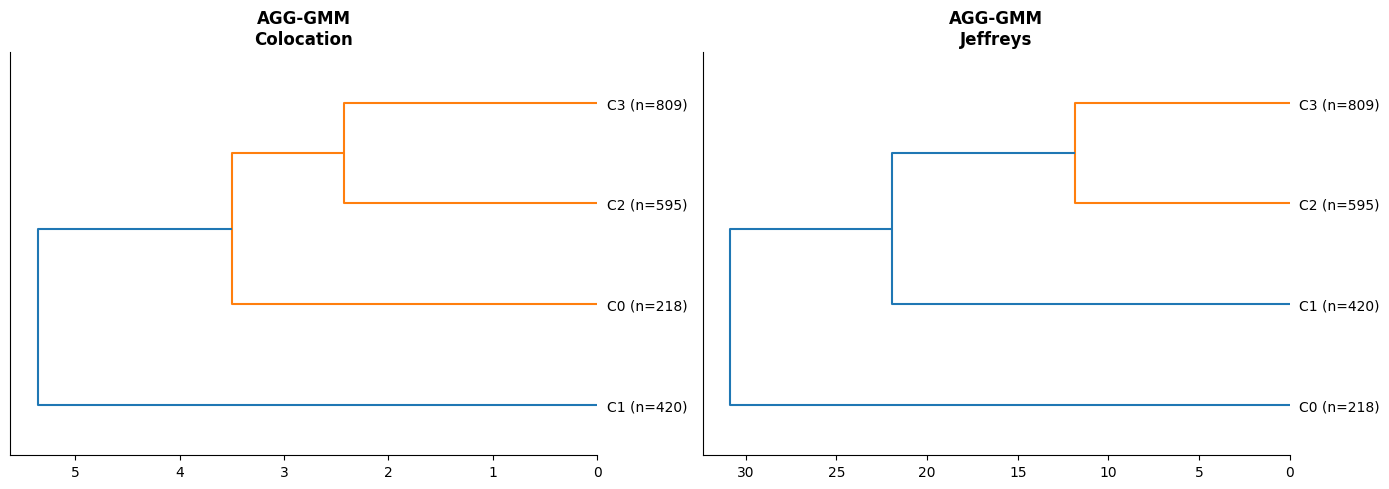

Significant features: 66

=== AGG-VBGMM ===


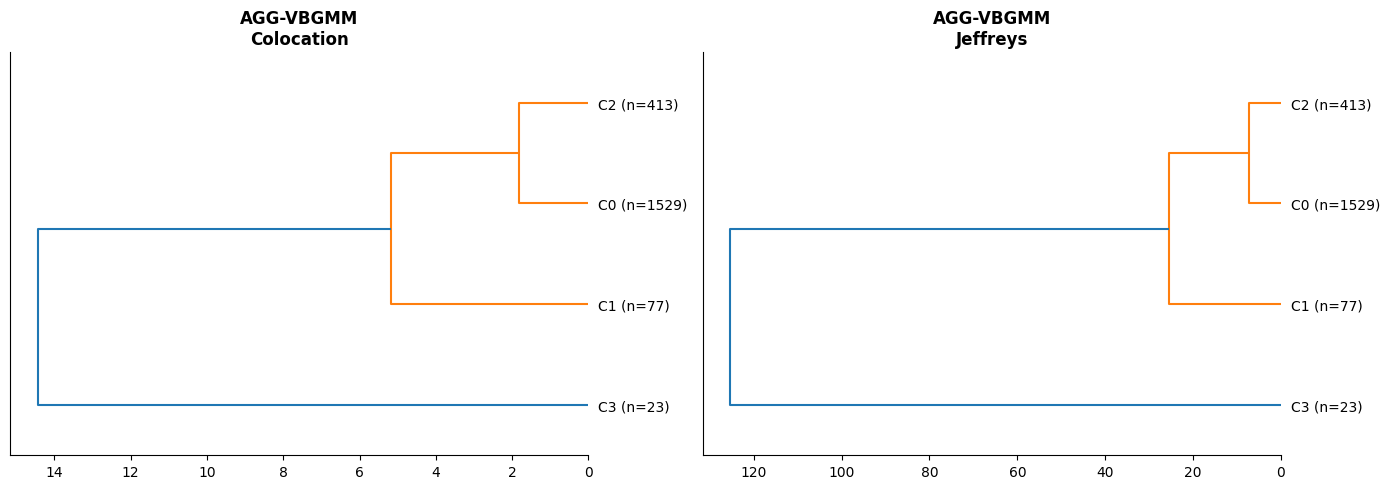

Significant features: 59

=== AGG-VBGMM34 ===


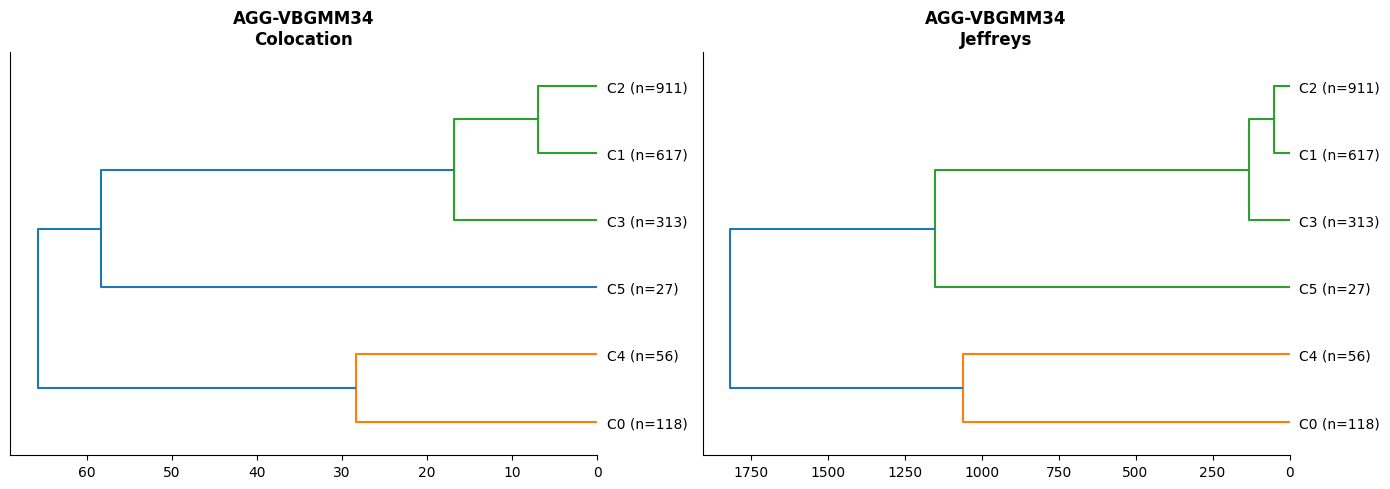

Significant features: 54

=== GNN-GMM ===


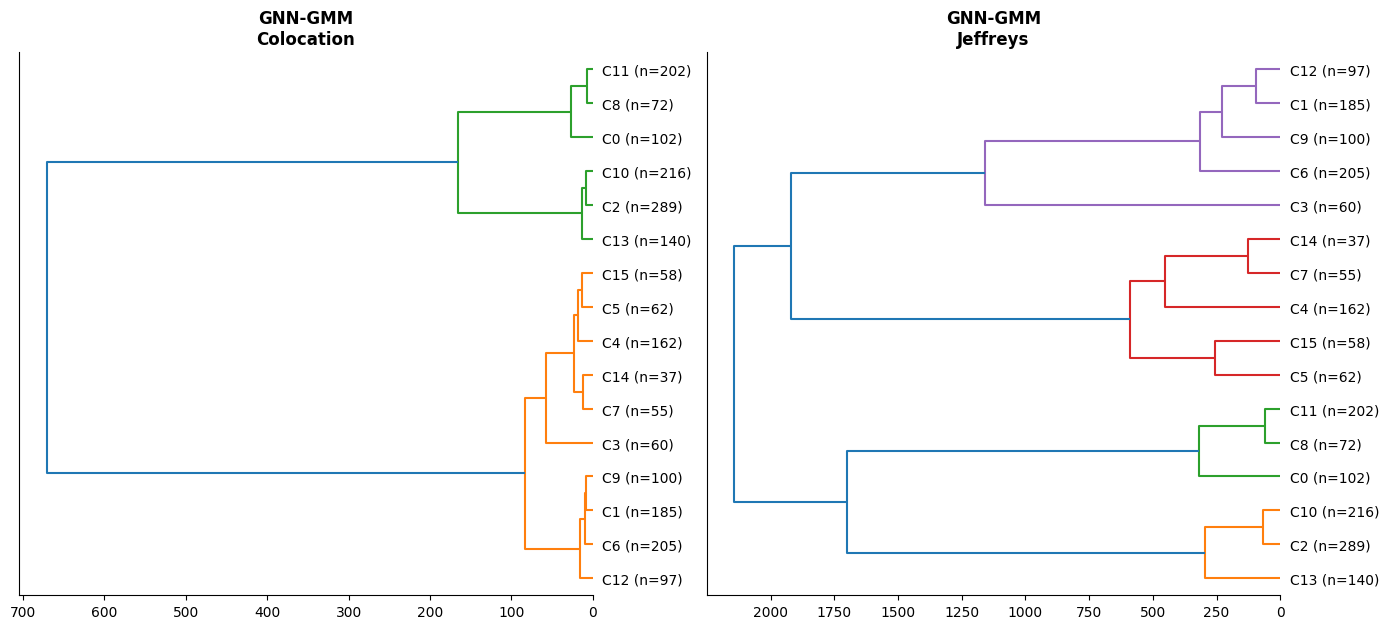

Significant features: 57

=== GNN-VBGMM ===


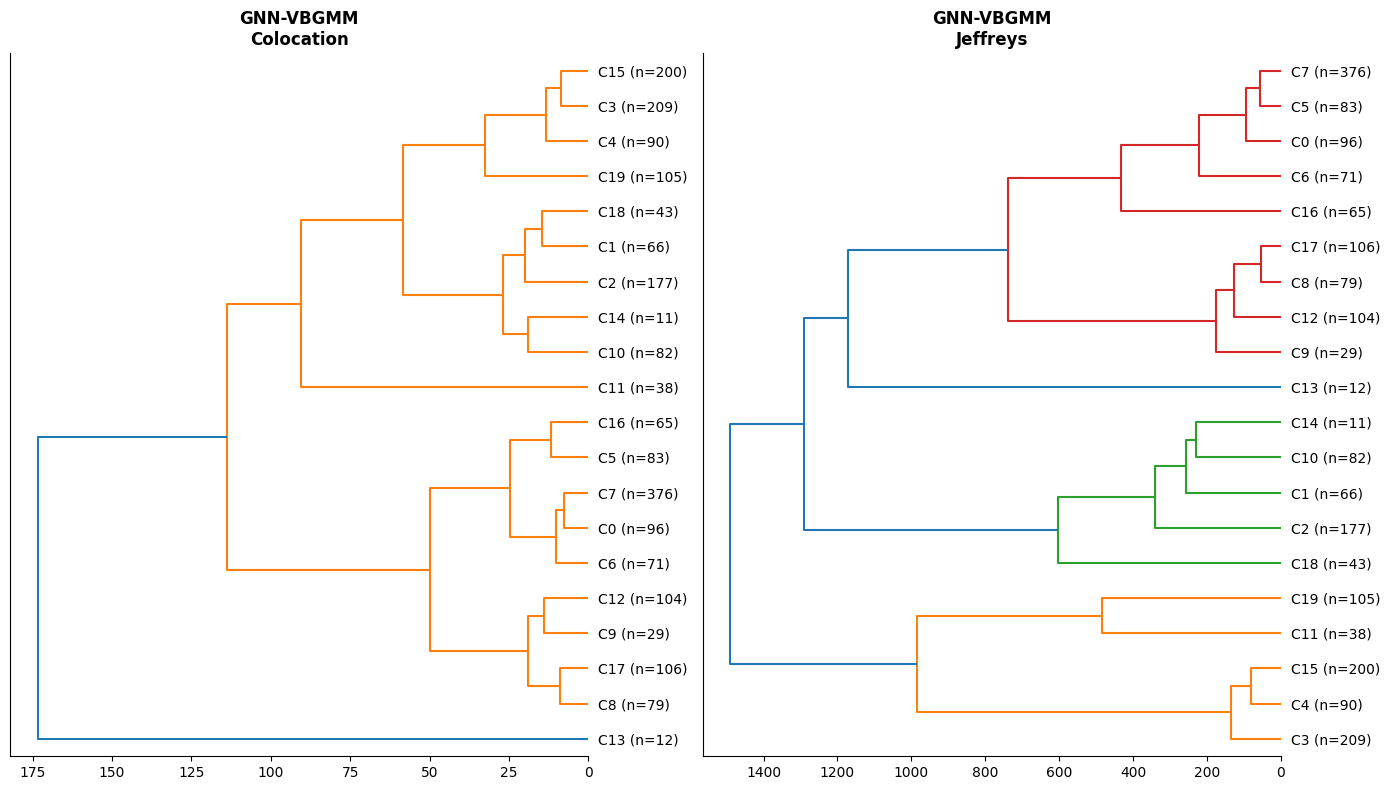

Significant features: 56


In [3]:
agg = pd.read_csv("../source/agg_final.csv")

models = {
    "AGG-GMM":   ("../results/classical_agg_10_GMM_QIn.npy",
                  "../source/agg_trans.csv"),
    "AGG-VBGMM": ("../results/classical_agg_10_vbgmm_QIn.npy",
                  "../source/agg_trans.csv"),
    "AGG-VBGMM34": ("../results/classical_agg_34_vbgmm_QIn.npy",
                    "../source/agg_trans.csv"),
    "GNN-GMM":   ("../results/GNN_s2s_10_GMM_QIn.npy",
                  "../source/GNN_set2set_ALL_FOLDS.csv"),
    "GNN-VBGMM": ("../results/GNN_s2s_10_vbgmm_QIn.npy",
                  "../source/GNN_set2set_ALL_FOLDS.csv"),
}

dfs_sc = {}
effects_sc = {}

for name, (qin_path, exp_path) in models.items():
    df, effects = run_model_pipeline(
        name, qin_path, exp_path, agg, evms,
        min_size=10,
        use_anova=False
    )

    dfs_sc[name] = df
    effects_sc[name] = effects
    
eff_mat = pd.concat(
    {k: v.set_index("feature")["effect"]
     for k, v in effects_sc.items()},
    axis=1
)

## The next plot shows the effect size of the different methods for the most important features
The result shows that for the high dimensional VBGMM the most important features are count os Pi-stacking and T-stacking. 
The GMM shows features which were also present in the supervised analysis. The VBGMM shows shome divergency.

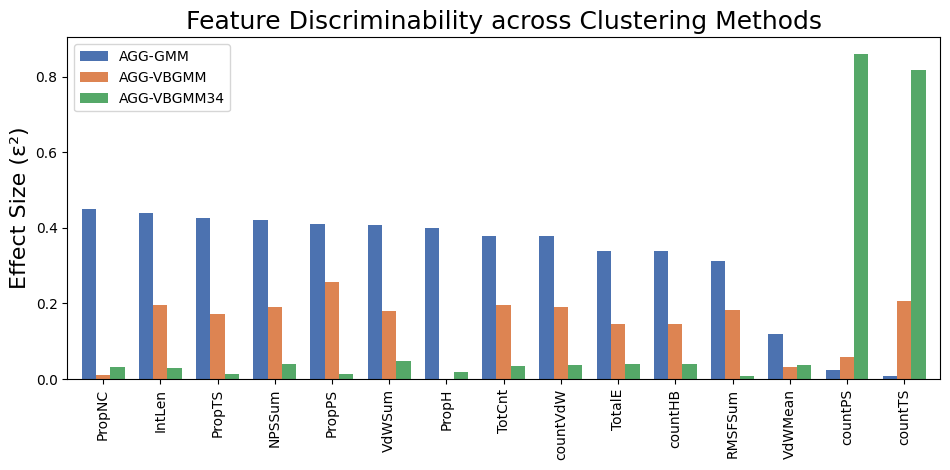

In [4]:
usan.plot_final_clustering_effects(eff_mat, '../source/feature_names2_accronyms.csv')
plt.savefig("../figures/effect_size_clustering.png")
plt.show()

## The next plot shows the heatmap of the effect size of the different methods
The stars indicate where the pvalue was significang. The value in each field shows the effect size. An effect size near 0 indicates that the features are not different between the clusters.

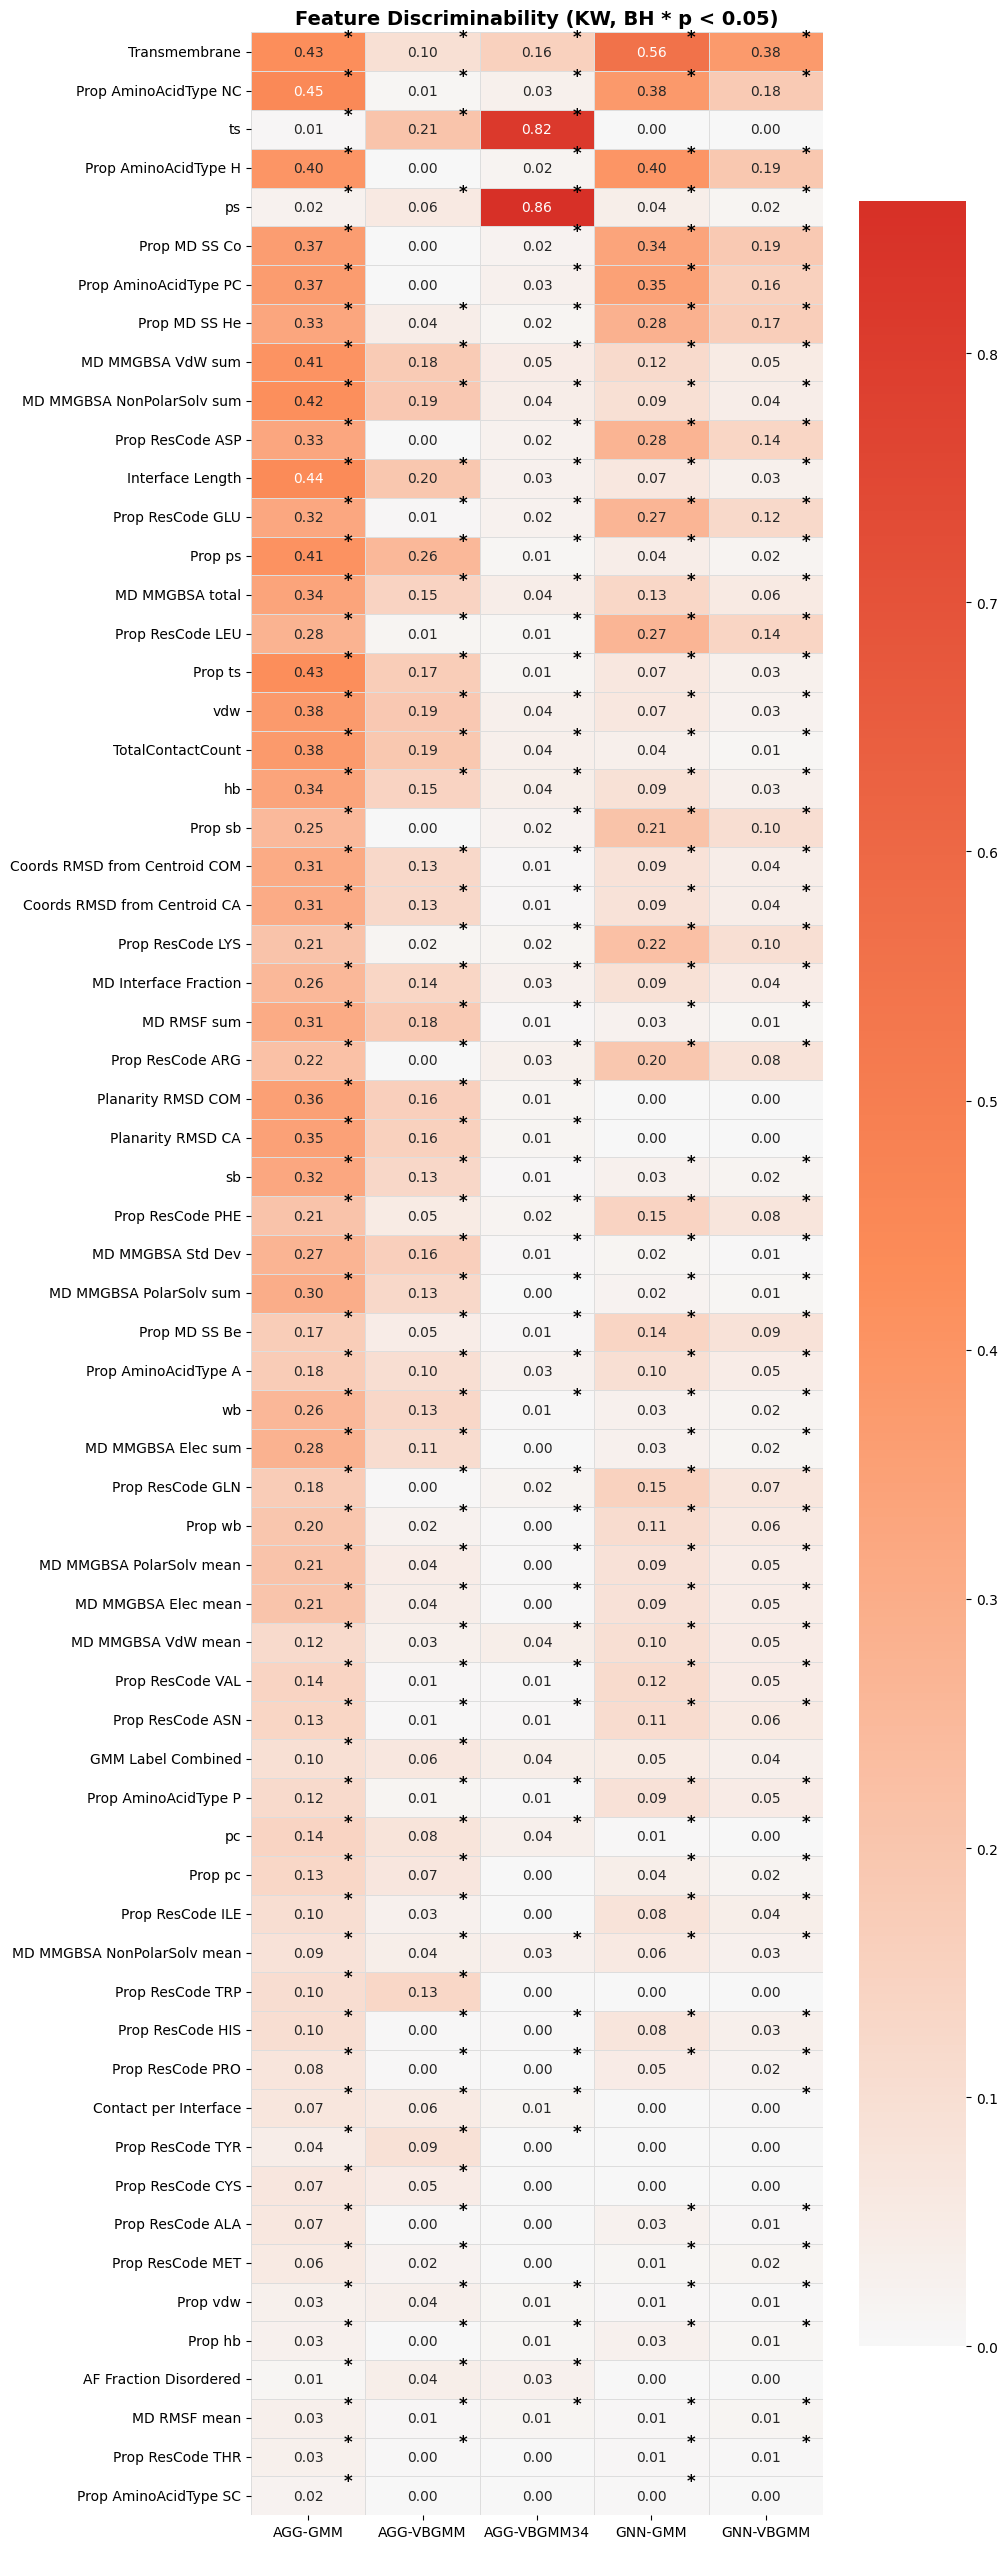

In [5]:
usan.plot_heatmap(effects_sc)